*GeoPlants Dataset*

**MileStone 2**

## Load Dataset

In [24]:
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os 
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, balanced_accuracy_score)

## CLF
## models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

### Import the created function
from src.utils import merge_metadata_data

In [2]:
## Path names
path_train = "dataset/train_join_agg.parquet"
path_test = "dataset/test_df.parquet"
ecoregions = "dataset/ecoregions/ser_l93.shp"

In [4]:
## Standard Training dataset load 
df = pd.read_parquet(path_train, engine='fastparquet')

## ETL on the dataset
## select index 
df.set_index("surveyId",inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

## X, y
Xtrain = df.drop(columns=columns_to_drop)
y = df[['predict']]


In [8]:
df_test

,lon,lat,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,average_Bio6,average_Bio7,average_Bio8,...,soilgrids_Soilgrid-bdod,soilgrids_Soilgrid-cec,soilgrids_Soilgrid-cfvo,soilgrids_Soilgrid-clay,soilgrids_Soilgrid-nitrogen,soilgrids_Soilgrid-phh2o,soilgrids_Soilgrid-sand,soilgrids_Soilgrid-silt,soilgrids_Soilgrid-soc,predict
surveyId,,,,,,,,,,,,,,,,,,,,,
3256,1.843658,42.580060,2735,93,3,6168,2876,2611,265,2755,...,109.0,246.0,193.0,210.0,547.0,59.0,370.0,419.0,717.0,0
9537,5.691200,46.332930,2841,80,3,6421,2971,2715,256,2800,...,122.0,255.0,140.0,329.0,430.0,63.0,241.0,429.0,513.0,1
11849,6.151231,43.083570,2894,63,2,5477,3013,2792,221,2867,...,131.0,238.0,118.0,292.0,195.0,72.0,307.0,401.0,322.0,0
15914,5.635420,44.983920,2841,92,3,6798,2981,2700,281,2846,...,124.0,198.0,196.0,244.0,342.0,65.0,354.0,400.0,459.0,1
18511,6.153073,43.108580,2894,68,2,5621,3018,2788,230,2865,...,142.0,196.0,139.0,293.0,235.0,72.0,304.0,403.0,253.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910272,4.560040,44.249200,2872,94,3,6499,3024,2743,281,2874,...,124.0,194.0,167.0,277.0,249.0,66.0,300.0,421.0,304.0,1
3914345,4.942220,43.880400,2883,100,3,6664,3041,2749,292,2885,...,149.0,201.0,147.0,223.0,187.0,76.0,275.0,501.0,236.0,0
3914752,3.831053,43.531047,2882,56,2,5249,2991,2789,202,2892,...,136.0,217.0,183.0,255.0,180.0,74.0,325.0,419.0,203.0,0


In [11]:
## Read test
df_test = pd.read_parquet(path_test, engine='fastparquet')

## Set index 
#df_test.set_index('surveyId',inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','predict']

# ## X, y
X_test = df_test.drop(columns=columns_to_drop)
y_test = df_test[['predict']]

In [12]:
df.shape, df_test.shape

((13501, 53), (1386, 49))

In [14]:
df.columns.difference(df_test.columns)

Index(['GRECO', 'codeser', 'index', 'speciesId'], dtype='object')

## Pre Processing

### Data Cleaning

We need to also  **preprocessing the test df** to fill some nan values but using the train data to input the mean and median

In [18]:
## pre process the data from a single function
## cleaner notebook
from src.preprocess import big_preprocessing_step, big_preprocessing_step_test

##pre process the dataset
X = big_preprocessing_step(Xtrain)


### TEST 
print("-"*100)
print()
print(f"RUNNING TEST")

X_test = big_preprocessing_step_test(X_test, Xtrain, X)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 96% percentile of the Pop2010: 2147483647.0
 The 96% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [21]:
X_test.columns == X.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

### PreProcessor

- StandarScaler
- OneHotEncoder

In [26]:
## Name cols
cat_cols = ["landcover_LandCover"]
not_cat_cols = [col for col in X.columns if col not in cat_cols]

numeric_features = not_cat_cols
categorical_features = cat_cols 

## Numeric features
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)


## Categorical Features
categorical_transformer = Pipeline(
                steps=[
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ##("selector", SelectPercentile(chi2, percentile=50)),
                ]
)

## Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [11]:
# Convert to DataFrame
X_transformed_df = pd.DataFrame(preprocessor.fit_transform(X),
                                columns=preprocessor.get_feature_names_out(),
                                index=X.index)


In [12]:
X_transformed_df

,num__average_Bio1,num__average_Bio2,num__average_Bio3,num__average_Bio4,num__average_Bio5,num__average_Bio6,num__average_Bio7,num__average_Bio8,num__average_Bio9,num__average_Bio10,...,cat__landcover_LandCover_5.0,cat__landcover_LandCover_8.0,cat__landcover_LandCover_9.0,cat__landcover_LandCover_10.0,cat__landcover_LandCover_11.0,cat__landcover_LandCover_12.0,cat__landcover_LandCover_13.0,cat__landcover_LandCover_14.0,cat__landcover_LandCover_16.0,cat__landcover_LandCover_17.0
surveyId,,,,,,,,,,,,,,,,,,,,,
333,0.347195,0.260223,0.401941,-0.783924,0.240344,0.530852,-0.408877,0.014173,0.601191,0.108783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
410,-0.137349,0.332205,0.401941,1.111207,0.167383,-0.400396,0.660988,-0.551047,-1.425111,0.108783,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
779,0.011741,0.116260,0.401941,-0.015829,0.057941,0.170369,-0.150633,-0.345513,-0.992833,-0.005940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,-0.137349,-0.099684,0.401941,0.066002,-0.124463,0.020168,-0.150633,-0.448280,-1.046868,-0.120663,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015,0.719922,0.836075,0.401941,1.352980,1.517168,0.140329,1.361934,1.118923,0.979434,1.179532,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-1.218257,0.188242,0.401941,-0.216687,-1.218883,-0.911081,-0.113742,1.195998,-1.722302,-1.306135,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3917646,1.539921,-0.027703,0.401941,0.246402,1.736052,1.131658,0.365853,0.784929,1.155046,1.676665,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3917824,-0.100077,-0.027703,0.401941,0.039965,-0.124463,0.080248,-0.224417,-0.396896,0.533647,-0.082422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cross-Validation Strategy

In [23]:
## concat dataset
Xx = pd.concat([X,df['GRECO']],axis=1).reset_index()
Xx = pd.concat([Xx,y], axis=1)

dict_train = {}
kfold = GroupKFold(n_splits=4,
                    random_state=420, shuffle=True
                   )

for i, (train_idx, test_idx) in enumerate(kfold.split(df['speciesId'],
                                                      df['predict'],
                                                      groups=df['GRECO'])):
    new_dict={}
    new_dict['train'] = train_idx
    new_dict['test']  = test_idx
    dict_train[i] = new_dict

for i in dict_train:
    print(f"    GFold: {i} - Train: {len(dict_train[i]['train'])} | Test:{len(dict_train[i]['test'])}")
for i in dict_train:   
    print(f"GFold: {i}  | Positive Rate: Train {y.iloc[dict_train[i]['train']]['predict'].mean():.3f} | Test: {y.iloc[dict_train[i]['test']]['predict'].mean():.3f} ")

    GFold: 0 - Train: 9461 | Test:4040
    GFold: 1 - Train: 8172 | Test:5329
    GFold: 2 - Train: 12162 | Test:1339
    GFold: 3 - Train: 10708 | Test:2793
GFold: 0  | Positive Rate: Train 0.432 | Test: 0.518 
GFold: 1  | Positive Rate: Train 0.537 | Test: 0.337 
GFold: 2  | Positive Rate: Train 0.475 | Test: 0.302 
GFold: 3  | Positive Rate: Train 0.401 | Test: 0.677 


In [24]:
## load the ecoregion
import re
path = 'dataset/ecoregions/ser_l93.shp'
ecogdf = gpd.read_file(path)

## Create a new column
ecogdf['GRECO'] = ecogdf['codeser'].apply(lambda x:re.findall(r'^(.+?)\d+$', x))
ecogdf['GRECO'] = ecogdf['GRECO'].apply(lambda x:x[0])

## Drop inconsistent values
ecogdf.drop(index=ecogdf.loc[ecogdf['codeser']=='-1'].index, axis=0, inplace=True)

## Convert to 4326 ## Match plant species
## Aggregate into the zones
ecogdf_4326 = ecogdf.to_crs("EPSG:4326").dissolve(by='GRECO')

GroupFold: 0
GRECO
J      3723
B      2269
C      1606
D+E     732
H       607
A       524
Name: count, dtype: int64
predict
0    5373
1    4088
Name: count, dtype: int64
GroupFold: 1
GRECO
B      2269
G      2118
F      1406
D+E     732
H       607
A       524
I+K     516
Name: count, dtype: int64
predict
1    4386
0    3786
Name: count, dtype: int64
GroupFold: 2
GRECO
J      3723
B      2269
G      2118
C      1606
F      1406
A       524
I+K     516
Name: count, dtype: int64
predict
0    6386
1    5776
Name: count, dtype: int64
GroupFold: 3
GRECO
J      3723
G      2118
C      1606
F      1406
D+E     732
H       607
I+K     516
Name: count, dtype: int64
predict
0    6418
1    4290
Name: count, dtype: int64


/tmp/ipykernel_97341/1409520789.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


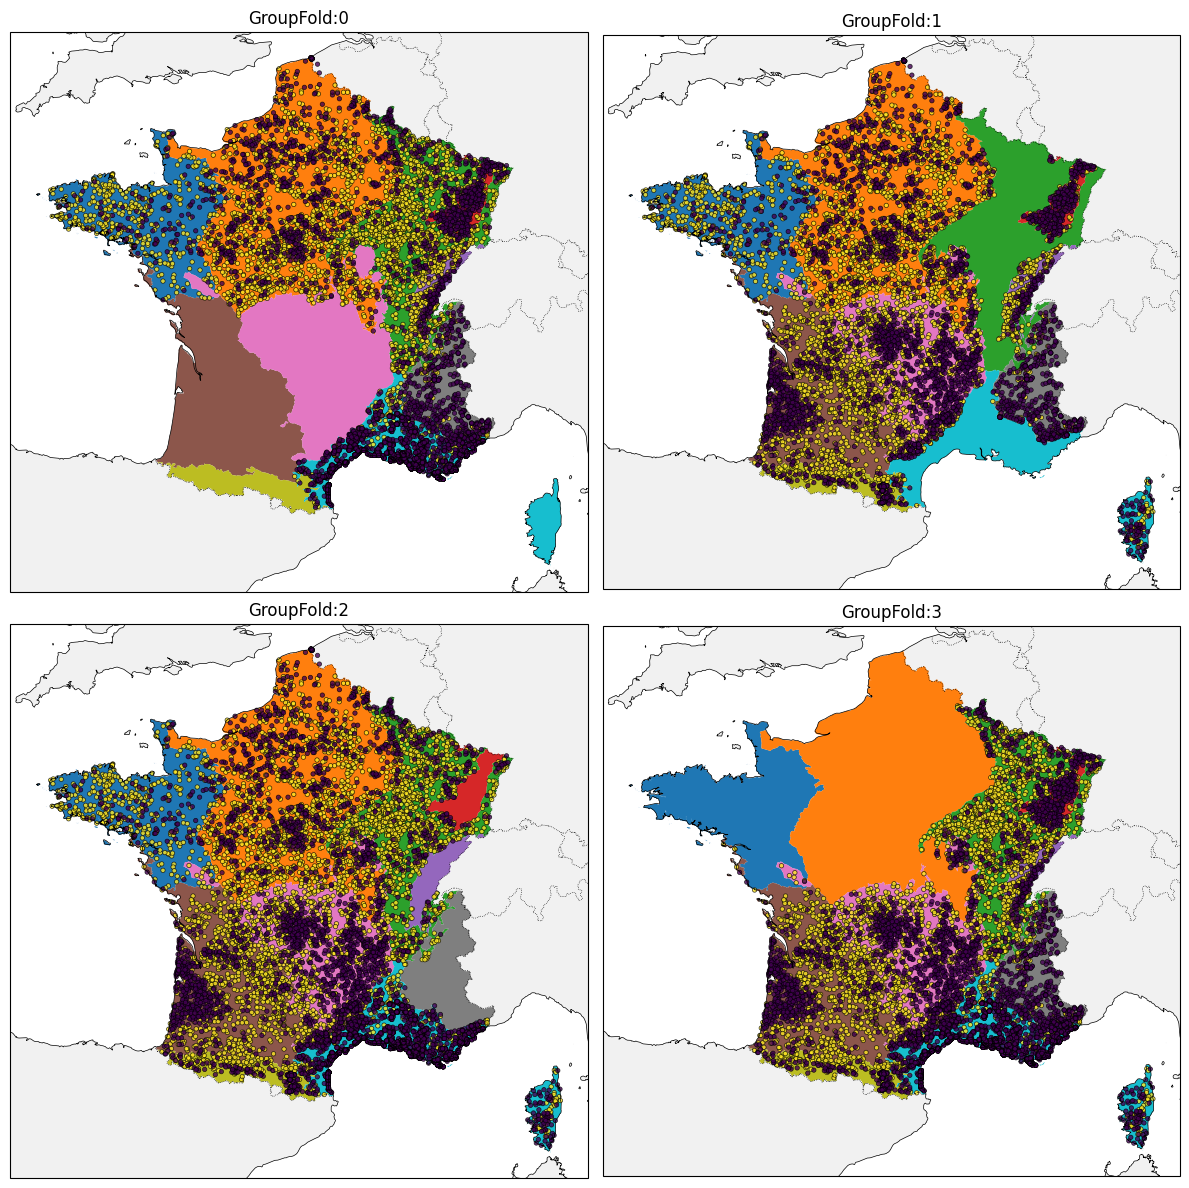

In [ ]:
## Plot to see it how the samples are being distributed
dff = df.iloc[dict_train[i]['train']]
gdf = gpd.GeoDataFrame(
                        dff,
                        geometry = gpd.points_from_xy(dff["lon"],
                                                     dff["lat"]),
                        crs="EPSG:4326"
)

fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                       )
ax = ax.flatten()
for i in dict_train.keys():
    ## select the df 
    dff = df.iloc[dict_train[i]['train']]
    print(f"GroupFold: {i}")
    print(dff['GRECO'].value_counts())
    print(dff['predict'].value_counts())
    gdf = gpd.GeoDataFrame(dff,
                            geometry = gpd.points_from_xy(dff["lon"],
                                                        dff["lat"]),
                            crs="EPSG:4326"
    )
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax[i].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.5) 
    
    ## plot the ecoregion
    ecogdf_4326.plot(column=ecogdf_4326.index,
                    ax=ax[i],
                    legend=False)

    gdf.plot(
        column='predict',
        cmap='viridis',
        legend=False,
        ax=ax[i],
        markersize=10,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    ax[i].set_title(f"GroupFold:{i}")

plt.tight_layout()
#plt.close()

## Evaluating a suite of ML Models

In [ ]:
from sklearn.model_selection import cross_validate
from src.inference import evaluate_with_group_kfold, describe_kfold_results
from src.plot import plot_cm



In [17]:
## Stardard X,y and Group
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment


Evaluating: KNN
- - - - - - - - - - 



------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.61      0.65      1948
           1       0.67      0.75      0.71      2092

    accuracy                           0.68      4040
   macro avg       0.68      0.68      0.68      4040
weighted avg       0.68      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.87      0.57      0.69      3535
           1       0.50      0.84      0.62      1794

    accuracy                           0.66      5329
   macro avg       0.69      0.70      0.66      5329
weighted avg       0.75      0.66      0.67      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       935
           1       0.55      0.54      0.55       404

    accuracy                           0.73      1339
   ma

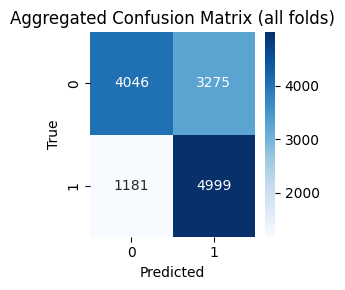

KNN | Time taken: 5.60

Evaluating: AdaBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.52      0.60      1948
           1       0.64      0.81      0.72      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.66      0.66      4040
weighted avg       0.68      0.67      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      3535
           1       0.64      0.66      0.65      1794

    accuracy                           0.76      5329
   macro avg       0.73      0.74      0.73      5329
weighted avg       0.76      0.76      0.76      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       935
           1       0.51      0.55      0.53    

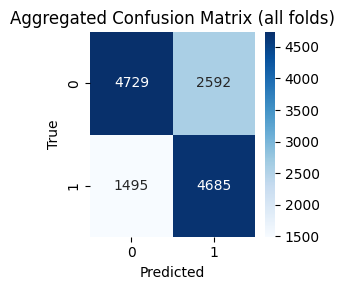

AdaBoost | Time taken: 68.63

Evaluating: LogisticRegression
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.71      0.58      0.64      1948
           1       0.67      0.78      0.72      2092

    accuracy                           0.68      4040
   macro avg       0.69      0.68      0.68      4040
weighted avg       0.69      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.71      0.17      0.28      3535
           1       0.35      0.86      0.49      1794

    accuracy                           0.40      5329
   macro avg       0.53      0.52      0.38      5329
weighted avg       0.59      0.40      0.35      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       935
           1       0.56      0.

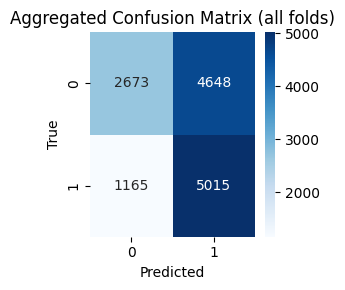

LogisticRegression | Time taken: 24.94

Evaluating: GaussianNB
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.82      0.28      0.42      1948
           1       0.58      0.94      0.72      2092

    accuracy                           0.62      4040
   macro avg       0.70      0.61      0.57      4040
weighted avg       0.70      0.62      0.58      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.86      0.35      0.50      3535
           1       0.41      0.89      0.56      1794

    accuracy                           0.53      5329
   macro avg       0.64      0.62      0.53      5329
weighted avg       0.71      0.53      0.52      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       935
           1       0.43      

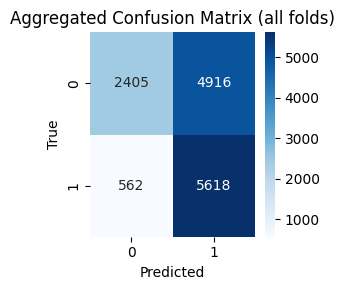

GaussianNB | Time taken: 0.99

Evaluating: SVC
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.59      0.64      1948
           1       0.66      0.75      0.71      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.67      0.67      4040
weighted avg       0.68      0.67      0.67      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      3535
           1       0.54      0.74      0.63      1794

    accuracy                           0.70      5329
   macro avg       0.69      0.71      0.69      5329
weighted avg       0.74      0.70      0.71      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       935
           1       0.54      0.79      0.64  

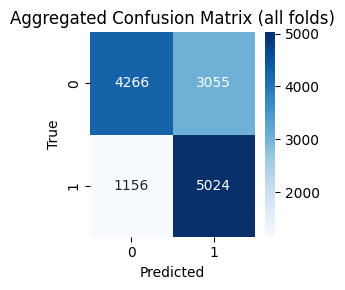

SVC | Time taken: 258.54

Evaluating: HistGradBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.67      0.56      0.61      1948
           1       0.65      0.75      0.69      2092

    accuracy                           0.66      4040
   macro avg       0.66      0.66      0.65      4040
weighted avg       0.66      0.66      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      3535
           1       0.44      0.60      0.50      1794

    accuracy                           0.60      5329
   macro avg       0.59      0.60      0.59      5329
weighted avg       0.64      0.60      0.61      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       935
           1       0.59      0.62      0

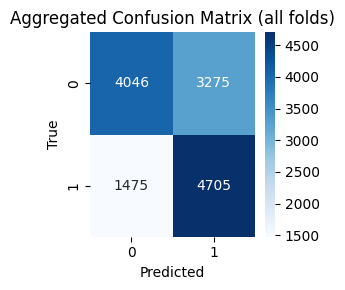

HistGradBoost | Time taken: 21.05

Evaluating: RF
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      1948
           1       0.67      0.78      0.72      2092

    accuracy                           0.69      4040
   macro avg       0.70      0.69      0.69      4040
weighted avg       0.69      0.69      0.69      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      3535
           1       0.60      0.55      0.57      1794

    accuracy                           0.72      5329
   macro avg       0.69      0.68      0.68      5329
weighted avg       0.72      0.72      0.72      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       935
           1       0.61      0.65      0.6

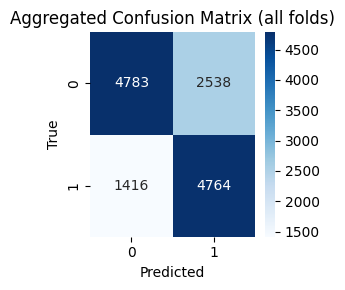

RF | Time taken: 89.34

Evaluating: Dummy_MostFrequent
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.48      1.00      0.65      1948
           1       0.00      0.00      0.00      2092

    accuracy                           0.48      4040
   macro avg       0.24      0.50      0.33      4040
weighted avg       0.23      0.48      0.31      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3535
           1       0.34      1.00      0.50      1794

    accuracy                           0.34      5329
   macro avg       0.17      0.50      0.25      5329
weighted avg       0.11      0.34      0.17      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       935
           1       0.00      0.00    

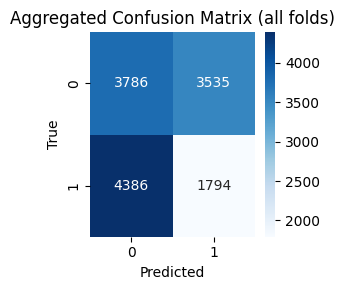

Dummy_MostFrequent | Time taken: 0.92

Evaluating: Dummy_Stratified
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.49      0.56      0.52      1948
           1       0.52      0.45      0.48      2092

    accuracy                           0.50      4040
   macro avg       0.50      0.50      0.50      4040
weighted avg       0.50      0.50      0.50      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.66      0.48      0.56      3535
           1       0.34      0.52      0.41      1794

    accuracy                           0.49      5329
   macro avg       0.50      0.50      0.48      5329
weighted avg       0.55      0.49      0.51      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.71      0.55      0.62       935
           1       0.31 

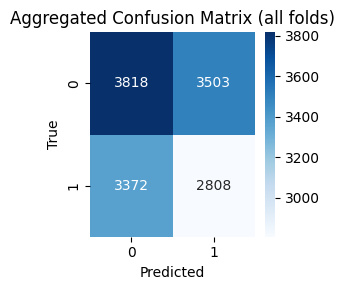

Dummy_Stratified | Time taken: 0.89


In [17]:
## suit of models
models = [
    ("KNN", KNeighborsClassifier(n_neighbors=50, n_jobs=-1)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=350, random_state=0)),
    ("LogisticRegression", LogisticRegression(max_iter=1000)),
    ("GaussianNB", GaussianNB()),
    ("SVC", SVC(probability=True, kernel='rbf', C=1.0, random_state=0)),
    ("HistGradBoost", HistGradientBoostingClassifier(max_iter=500, random_state=0)),
    ("RF", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1)),
    ("Dummy_MostFrequent",DummyClassifier(strategy="most_frequent")),
    ("Dummy_Stratified",DummyClassifier(strategy="stratified")),
]

# dict to store results
big_dict_all_classifiers = {}

# Loop through models
for model_name, model in models:
    print(f"\n{'='*100}")
    print(f"Evaluating: {model_name}")
    print(f"{'- '*10}\n")
    
    start_time = time.time()
    
    # Create pipeline
    clf = Pipeline([
        ("preproc", preprocessor),
        (model_name, model)
    ])
    
    # Evaluate
    scores = evaluate_with_group_kfold(clf, X, y_vec, groups, verbose=True)
    
    # Create DataFrame from scores
    df_scores = pd.DataFrame(scores)
    
    # Display results
    print(f"\n--- Results for {model_name} ---")
    describe_kfold_results(df_scores)
    
    # Plot confusion matrix
    total_cm = np.sum(df_scores["confusion_matrix"].to_list(), axis=0)
    plot_cm(total_cm, figsize=(3,3))
    
    # Store results
    big_dict_all_classifiers[model_name] = df_scores
    
    time_taken =  time.time() - start_time
    print(f"{model_name} | Time taken: {time_taken:.2f}")

In [18]:
print("oi")

oi


In [ ]:
from src.utils import export_cv_clfs_metrics
        
## exporting my table in folder
df_result = export_cv_clfs_metrics(big_dict_all_classifiers,
                       export=True,
                       file_name='model_results_d')


,recall,precision,f1,accuracy,balanced_accuracy,roc_auc,confusion_matrix
0,0.502970,0.505934,0.501191,0.502970,0.505200,0.493790,"[[1106, 842], [1166, 926]]"
1,0.485082,0.549225,0.498477,0.485082,0.495481,0.485090,"[[1639, 1896], [848, 946]]"
2,0.531740,0.596190,0.550610,0.531740,0.521322,0.476386,"[[512, 423], [204, 200]]"
3,0.477981,0.571634,0.490510,0.477981,0.509610,0.495632,"[[541, 362], [1096, 794]]"


## ploting

In [ ]:
## Construct a multi-level df 
## the first column level is the name of the classifier and the second level are the metrics 
big_dict = big_dict_all_classifiers.copy()
dfs = []
for model_name, df in big_dict.items():
    # first level = model name, second level = metric name
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    dfs.append(df)

# concat
multi_df = pd.concat(dfs, axis=1)

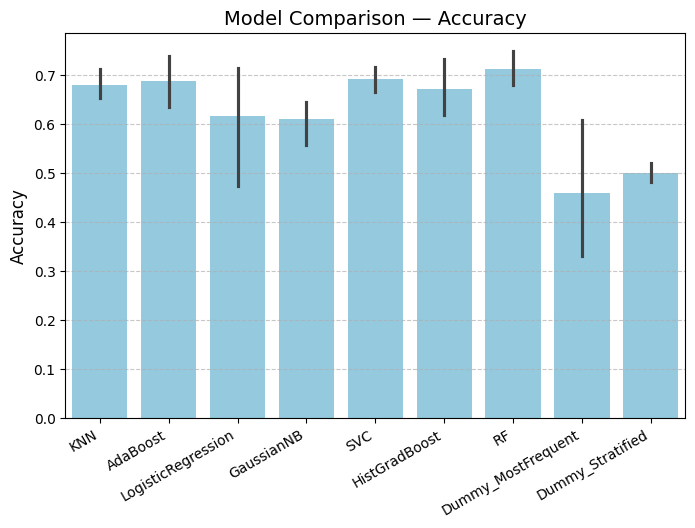

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=multi_df.xs('accuracy', level=1, axis=1),
            color='skyblue')
plt.title('Model Comparison — Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Plotting in R 
cause R is cooler :)

In [19]:
%load_ext rpy2.ipython  

In [ ]:
## vars 
file_output = "result_imgs/my_plot2.png"
width = 9
height = 7
dpi=100

"#E6E6E8"

In [37]:
%%R -i file_output,width,height,dpi

library(ggplot2)
suppressMessages(library(dplyr))
suppressMessages(library(tidyverse))

## figsize
## options(repr.plot.width = 10, repr.plot.height = 8)

# Load
dataf <- readr::read_csv("tmp_csv/model_results_d.csv", col_names=TRUE, show_col_types = FALSE)
metrics_col <- c("recall","precision","f1","accuracy","balanced_accuracy","roc_auc")

## exclude confusion matrix
datafilter <- dataf |> 
                    filter(metric != "confusion_matrix") |>
                    mutate(value = as.numeric(value))
# plot
p <- ggplot(datafilter |> filter(metric != "kfold"),
            aes(x = model, y = value, fill = metric)
        ) +
  stat_summary(fun = mean, geom = "bar", position = "dodge") +
  stat_summary(fun.data = mean_se, geom = "errorbar", 
               #position = position_dodge(width = 0.9),
                width = 0.05, color='#444343ff') +
  labs(title = "Comparison of Models",
       x = NULL, y = "Score") +
    scale_fill_brewer(palette = "Blues")+
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
            plot.background = element_rect(fill = "#E6E6E8", color = NA),
            plot.title = element_text(hjust = 0.5, face = "bold"),
            panel.grid.minor.y = element_blank()
        ) 
    
##print(p) 

ggsave(file_output,    
       width = width,           
       height = height,          
       dpi = dpi)  

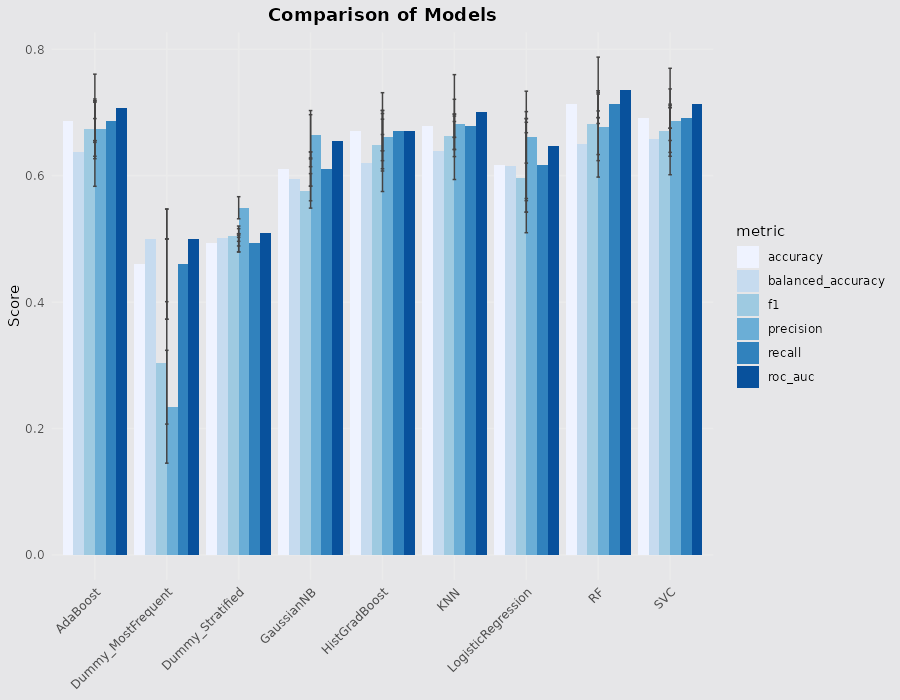

In [38]:
from IPython.display import Image

Image(file_output, width=width*dpi, height=height*dpi)

## Feature Selection for better accuracy

Permutation Importance

Uses permutation to understand how the features affect the error

## To do:
- increase n_splits
- increase plot
- fix the cell
- make it more accessible
- save the better performance features and print it 
- use the same number of estimator for each rf
- 

In [72]:
perm_vals[0]

array([ 1.38613861e-03, -4.45544554e-04,  5.94059406e-04,  4.95049505e-05,
       -4.50495050e-03, -8.41584158e-04, -7.42574257e-04,  5.54455446e-03,
        2.77227723e-03, -1.33663366e-03, -4.50495050e-03,  1.73267327e-03,
        2.27722772e-03, -5.94059406e-04,  5.44554455e-03,  1.58415842e-03,
       -2.77227723e-03,  1.23762376e-03,  1.04950495e-02,  1.51980198e-02,
        5.24752475e-03,  5.49504950e-03,  1.33663366e-03, -4.30693069e-03,
       -1.58415842e-03,  4.00990099e-03, -4.60396040e-03, -1.53465347e-03,
        9.90099010e-05,  1.93069307e-03,  4.95049505e-04,  1.03960396e-03,
        4.95049505e-05,  1.38613861e-03,  3.96039604e-04,  0.00000000e+00,
       -2.97029703e-04, -1.08910891e-03, -2.97029703e-04])

In [77]:
perm_arr.shape

(4, 39)

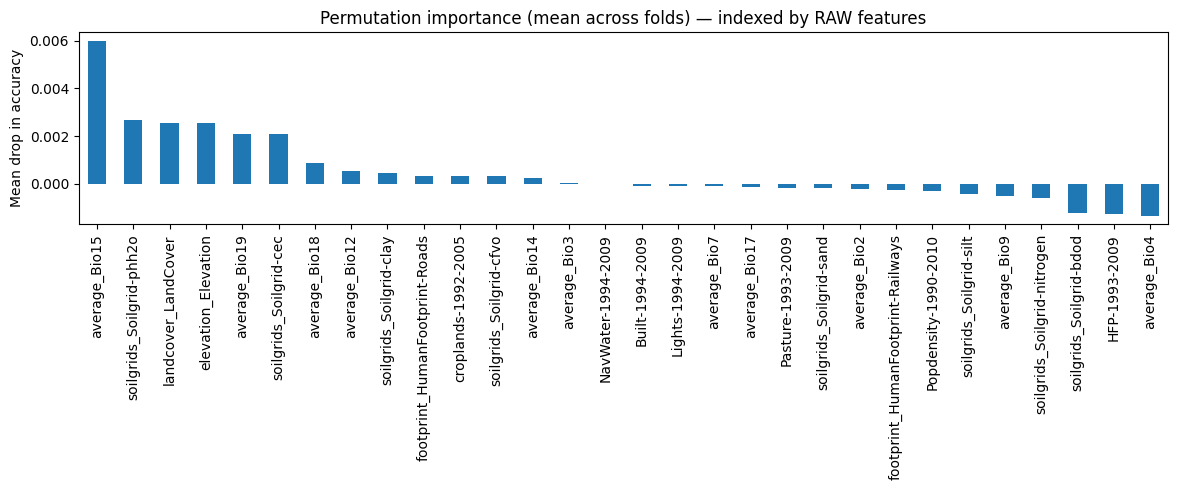

average_Bio15                        0.005984
soilgrids_Soilgrid-phh2o             0.002669
landcover_LandCover                  0.002563
elevation_Elevation                  0.002529
average_Bio19                        0.002100
soilgrids_Soilgrid-cec               0.002072
average_Bio18                        0.000868
average_Bio12                        0.000549
soilgrids_Soilgrid-clay              0.000455
footprint_HumanFootprint-Roads       0.000325
croplands-1992-2005                  0.000319
soilgrids_Soilgrid-cfvo              0.000319
average_Bio14                        0.000256
average_Bio3                         0.000019
NavWater-1994-2009                   0.000000
Built-1994-2009                     -0.000089
Lights-1994-2009                    -0.000090
average_Bio7                        -0.000108
average_Bio17                       -0.000153
Pasture-1993-2009                   -0.000172
soilgrids_Soilgrid-sand             -0.000182
average_Bio2                      

In [ ]:
from sklearn.inspection import permutation_importance

n_splits = 4
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420) ## same for whole notebook 

groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

perm_vals = []
for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=500,
                                       random_state=0,
                                       n_jobs=-1)
        )
    ])
    
    
    pipe.fit(X_train, y_train) 

    # compute permutation importance on the raw X_test
    r = permutation_importance(pipe,
                               X_test,
                               y_test,
                               n_repeats=5, random_state=0, n_jobs=-1,
                               scoring=['accuracy','recall'])
    
    print(f"Fold {fold_i}: perm importances shape = {r['accuracy'].importances_mean.shape}, raw features = {len(X.columns.to_list())}")
    
    ## now the r is a dictionary with accuracy, recall 
    perm_vals.append(r['accuracy'].importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=(X.columns.to_list())).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()



In [ ]:
perm_series

average_Bio15                        0.005984
soilgrids_Soilgrid-phh2o             0.002669
landcover_LandCover                  0.002563
elevation_Elevation                  0.002529
average_Bio19                        0.002100
soilgrids_Soilgrid-cec               0.002072
average_Bio18                        0.000868
average_Bio12                        0.000549
soilgrids_Soilgrid-clay              0.000455
footprint_HumanFootprint-Roads       0.000325
croplands-1992-2005                  0.000319
soilgrids_Soilgrid-cfvo              0.000319
average_Bio14                        0.000256
average_Bio3                         0.000019
NavWater-1994-2009                   0.000000
Built-1994-2009                     -0.000089
Lights-1994-2009                    -0.000090
average_Bio7                        -0.000108
average_Bio17                       -0.000153
Pasture-1993-2009                   -0.000172
soilgrids_Soilgrid-sand             -0.000182
average_Bio2                      

In [ ]:
# threshold (0 means dropping negative and zero)
threshold = 0.0
keep_features = perm_series[perm_series > threshold].index.tolist()
drop_features = [f for f in X.columns if f not in keep_features]

print(f"Keeping {len(keep_features)} features, dropping {len(drop_features)} features")
print(f"The selected features are: {}") ## Print selected Features 

## Select new X
X_reduced = X[keep_features].copy()
groups_reduced = df.loc[X_reduced.index, 'GRECO']


cat_cols = [c for c in X_reduced.columns if c.startswith('landcover') or X_reduced[c].dtype == 'object']
num_cols = [c for c in X_reduced.columns if c not in cat_cols]


## Re-use the preprocessor
pipe_reduced = Pipeline([("preproc", preprocessor),
                         ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))])

print("\nEvaluating RF on reduced feature set:")
res_reduced = evaluate_with_group_kfold(pipe_reduced,
                                        X_reduced,
                                        y_vec,
                                        groups=groups_reduced
                                        )

# Evaluate original (on full X) and reduced (X_reduced)
print("Evaluating original RF on full X:")
res_full = evaluate_with_group_kfold(Pipeline([("preproc", preprocessor),
                                               ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))]
                                              ),
                                                X, ##full X
                                                y_vec,
                                                groups=df.loc[X.index,'GRECO'],
                                                verbose=True)


df_scores_full = pd.DataFrame(res_full)
df_scores_red = pd.DataFrame(res_reduced)

describe_kfold_results(df_scores_full)
describe_kfold_results(df_scores_red)

## FINISH
break

print("\nMean accuracy full: {:.4f}".format(res_full['summary_df']['accuracy'].mean()))
print("Mean accuracy reduced: {:.4f}".format(res_reduced['summary_df']['accuracy'].mean()))


Keeping 20 features, dropping 19 features
Evaluating original RF on full X:
Fold 0 — acc:0.7994, prec:0.3329, rec:0.4743, f1:0.3912, roc_auc:0.7620478411993596
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.47      0.39       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.64      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.7070, prec:0.6589, rec:0.9127, f1:0.7653, roc_auc:0.7644617660668094
              precision    recall  f1-score   support

           0       0.83      0.48      0.61      1616
           1       0.66      0.91      0.77      1776

    accuracy                           0.71      3392
   macro avg       0.75      0.70      0.69      3392
weighted avg       0.74      0.71      0.69      3392

Fold 2 — acc:0.6894, prec:0.6643, rec:0.7782, f1:0.7168, roc_auc:0.7486370568721712
              prec

Questions:


- Which are these 20 features choosen???
- How much was the improvement? Where are the variables that store it?
- Why are you building up the processor everytime??

## Trying to drop Human footprint

## TO DO:
 - fix the code below
 - plot a graph showing the results of Xfull, Xred and X_mod
 - Highlight the difference (if higher or lower)

X_mod shape: (13501, 30)
Fold 0 — acc:0.7983, prec:0.3277, rec:0.4605, f1:0.3829, roc_auc:0.7550282528219034
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.46      0.38       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.63      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.6549, prec:0.6549, rec:0.9980, f1:0.7908, roc_auc:0.6292378079643938
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       786
           1       0.65      1.00      0.79      1483

    accuracy                           0.65      2269
   macro avg       0.66      0.50      0.40      2269
weighted avg       0.66      0.65      0.52      2269

Fold 2 — acc:0.7158, prec:0.6826, rec:0.7336, f1:0.7072, roc_auc:0.7922504850665752
              precision    recall  f1-score   support

           0  

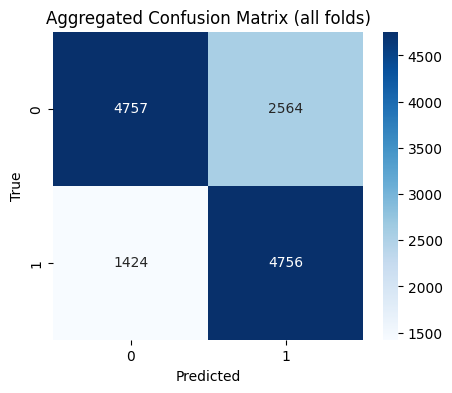

In [ ]:
hf_cols = [
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'
]

X_mod = X.drop(columns=[c for c in hf_cols if c in X.columns]).copy()
groups_mod = df.loc[X_mod.index, 'GRECO']

print("X_mod shape:", X_mod.shape)

# Rebuild a local preprocessor from X_mod columns
pipe_mod = Pipeline([("preproc", preprocessor),
                     ("clf", RandomForestClassifier(n_estimators=1500, random_state=0, n_jobs=-1))])

res_rf_mod = evaluate_with_group_kfold(pipe_mod,
                                          X_mod,
                                          y_vec,
                                          groups=groups_mod,
                                          verbose=True)

df_scores_red = pd.DataFrame(res_rf_mod)
describe_kfold_results(df_scores_full)

## how much this improved??

## PCA

Here we are trying PCA to see if the Dataset perform better with PCA

- Try to use 3/4 axis and re-run the model
- Use pca to make feature selection and again re-run the model
- - save image and results in case takes time to run

## Grid Search

- Select 2/3 models and apply a completly grid search for each model]
  

## Error Evaluation

-Here we are tring to evaluate the error of the model.
- Lets focus on see if we find bias on the prediction and how the spatial distribution the error is given
- For the same area, try to apply some UMAP to see if the feature space is very similar and therefore the model is predicting a true label as false

## Testing the models

Here we gonna train the choose ML model in the full dataset with the hyperparameters tunned and apply to the yTEST

Lets repeat this with the full Xtrain features and with the Xtrain features selected.

### Training the model with the whole X.

In [22]:
from src.inference import train_test_predict

In [42]:
## model
models = [
    ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
]


## Run the prediction 
scores = train_test_predict(X, X_test, y, y_test, models, preprocessor)

Training the Model


Training time: 35.97306513786316
Predicting train
Predicting test
Time taken: 41.98


## 

In [43]:
for name in scores.keys():
    print(name)
    for k, v in scores[name].items():
        val = v[0]
        formatted = f"{val:.3f}" if isinstance(val, float) else str('')
        print(f"{k}: {formatted}")
    print("-" * 30)

train
recall: 0.998
precision: 0.998
f1: 0.998
accuracy: 0.998
balanced_accuracy: 0.998
roc_auc: 1.000
confusion_matrix: 
------------------------------
test
recall: 0.303
precision: 0.675
f1: 0.156
accuracy: 0.303
balanced_accuracy: 0.504
roc_auc: 0.561
confusion_matrix: 
------------------------------


In [34]:
X

,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,average_Bio6,average_Bio7,average_Bio8,average_Bio9,average_Bio10,...,soilgrids_Soilgrid-soc,footprint_HumanFootprint-Railways,footprint_HumanFootprint-Roads,Built-1994-2009,croplands-1992-2005,Lights-1994-2009,NavWater-1994-2009,Pasture-1993-2009,Popdensity-1990-2010,HFP-1993-2009
surveyId,,,,,,,,,,,,,,,,,,,,,
333,-271.885,0.81,0.03,52.85,-270.645,-272.885,2.24,-272.195,-271.195,-271.195,...,257.0,0.0,0.0,0.0,0.00,3.00,0.0,0.0,0.0,3.0
410,-272.015,0.82,0.03,63.04,-270.665,-273.195,2.53,-272.415,-272.695,-271.195,...,338.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0
779,-271.975,0.79,0.03,56.98,-270.695,-273.005,2.31,-272.335,-272.375,-271.225,...,238.0,0.0,0.0,0.0,-7.00,0.00,0.0,0.0,1.0,-6.0
1218,-272.015,0.76,0.03,57.42,-270.745,-273.055,2.31,-272.375,-272.415,-271.255,...,232.0,4.0,8.0,0.0,1.75,1.00,0.0,0.0,0.0,1.0
2015,-271.785,0.89,0.03,64.34,-270.295,-273.015,2.72,-271.765,-270.915,-270.915,...,227.0,8.0,4.0,0.0,0.00,1.25,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-272.305,0.80,0.03,55.90,-271.045,-273.365,2.32,-271.735,-272.915,-271.565,...,503.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0
3917646,-271.565,0.77,0.03,58.39,-270.235,-272.685,2.45,-271.895,-270.785,-270.785,...,233.0,0.0,1.0,0.0,0.00,-1.00,0.0,0.0,1.0,0.0
3917824,-272.005,0.77,0.03,57.28,-270.745,-273.035,2.29,-272.355,-271.245,-271.245,...,264.0,0.0,2.0,0.0,-1.75,0.00,0.0,0.0,1.0,1.0


In [35]:
X_test

,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,average_Bio6,average_Bio7,average_Bio8,average_Bio9,average_Bio10,...,soilgrids_Soilgrid-soc,footprint_HumanFootprint-Railways,footprint_HumanFootprint-Roads,Built-1994-2009,croplands-1992-2005,Lights-1994-2009,NavWater-1994-2009,Pasture-1993-2009,Popdensity-1990-2010,HFP-1993-2009
surveyId,,,,,,,,,,,,,,,,,,,,,
3256,0.35,9.3,0.3,616.8,14.45,-12.05,26.5,2.35,-6.25,8.55,...,717.0,0.0,1.0,0.0,7.0,0.0,0.0,-0.25,1.0,8.0
9537,10.95,8.0,0.3,642.1,23.95,-1.65,25.6,6.85,6.85,19.25,...,513.0,4.0,1.0,0.0,-7.0,0.0,0.0,0.00,0.0,-7.0
11849,16.25,6.3,0.2,547.7,28.15,6.05,22.1,13.55,23.55,23.55,...,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
15914,10.95,9.2,0.3,679.8,24.95,-3.15,28.1,11.45,19.75,19.75,...,459.0,8.0,4.0,0.0,0.0,1.0,0.0,0.00,0.0,1.0
18511,16.25,6.8,0.2,562.1,28.65,5.65,23.0,13.35,23.75,23.75,...,253.0,0.0,4.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910272,14.05,9.4,0.3,649.9,29.25,1.15,28.1,14.25,22.75,22.75,...,304.0,0.0,0.0,0.0,-3.5,2.0,0.0,0.00,1.0,3.0
3914345,15.15,10.0,0.3,666.4,30.95,1.75,29.2,15.35,24.05,24.05,...,236.0,0.0,4.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
3914752,15.05,5.6,0.2,524.9,25.95,5.75,20.2,16.05,22.05,22.05,...,203.0,8.0,1.0,0.0,0.0,1.0,0.0,0.00,1.0,2.0


In [28]:
X.shape, X_test.shape, y.shape, y_test.shape

((13501, 39), (1386, 39), (13501, 1), (1386, 1))

In [41]:

def train_test_predict(X_train, X_test, y_train, y_test, models,preprocessor):
    """
    Predict the model for the given Xtrain and Xtest.
    """
    import numpy as np
    import time
    ## scores dict
    scores = {
            'recall': [], 'precision': [], 'f1': [], 
            'accuracy': [], 'balanced_accuracy': [], 'roc_auc': [],
            'confusion_matrix': []
        }

    ## time
    start_time = time.time()

    # Create pipeline
    clf = Pipeline([
        ("preproc", preprocessor),
        (models[0][0], models[0][1])
    ])

    ##fit 
    print(f"Training the Model")
    clf.fit(X_train, y_train)
    print(f"Training time: {np.absolute(time.time()-start_time)}")
        
    ## predict 
    list_loop = [
        ('train', X_train, y_train),
        ('test', X_test, y_test)
        ]
    
    dict_out = {}

    for name, df, y_vec in list_loop:
        print(f"Predicting {name}")

        # Create a fresh score dict for each loop iteration
        scores = {
            'recall': [], 'precision': [], 'f1': [], 
            'accuracy': [], 'balanced_accuracy': [], 'roc_auc': [],
            'confusion_matrix': None
        }

        y_pred = clf.predict(df)

        # Evaluate
        y_score = None
        if hasattr(clf, "predict_proba"):
            try:
                y_score = clf.predict_proba(df)[:, 1]
            except Exception:
                pass

        # Metrics
        scores['recall'].append(recall_score(y_vec, y_pred, average='weighted'))
        scores['precision'].append(precision_score(y_vec, y_pred, average='weighted'))
        scores['f1'].append(f1_score(y_vec, y_pred, average='weighted'))
        scores['accuracy'].append(accuracy_score(y_vec, y_pred))
        scores['balanced_accuracy'].append(balanced_accuracy_score(y_vec, y_pred))

        if y_score is not None and len(np.unique(y_pred)) > 1:
            try:
                scores['roc_auc'].append(roc_auc_score(y_vec, y_score))
            except Exception:
                pass

        scores['confusion_matrix'] = confusion_matrix(y_vec, y_pred, labels=[0, 1])
        
        dict_out[name] = scores 
        
    time_taken =  time.time() - start_time
    print(f"Time taken: {time_taken:.2f}")
    
    return dict_out

In [29]:
    list_loop = [
        ('train', 1, 3),
        ('test', 2, 4)
        ]
    
    for name, df, y_vec in list_loop:
        print(name,df,y_vec)

train 1 3
test 2 4


In [36]:
scores

{'train': {'recall': [0.9980742167246871, 0.30303030303030304],
  'precision': [0.9980750749798241, 0.6751727804359383],
  'f1': [0.9980740942295446, 0.15551148081268565],
  'accuracy': [0.9980742167246871, 0.30303030303030304],
  'balanced_accuracy': [0.9979973158741378, 0.5039922410682064],
  'roc_auc': [0.5610903103572717],
  'confusion_matrix': array([[ 15, 963],
         [  3, 405]])},
 'test': {'recall': [0.9980742167246871, 0.30303030303030304],
  'precision': [0.9980750749798241, 0.6751727804359383],
  'f1': [0.9980740942295446, 0.15551148081268565],
  'accuracy': [0.9980742167246871, 0.30303030303030304],
  'balanced_accuracy': [0.9979973158741378, 0.5039922410682064],
  'roc_auc': [0.5610903103572717],
  'confusion_matrix': array([[ 15, 963],
         [  3, 405]])}}